In [17]:
import imp
import sys
import random
import networkx as nx
import osmnx as ox
import rasterio
import matplotlib.pyplot as plt
from collections import Counter

#NOTE by default OSM doesnt call the bicycle and cycleway info for performance reasons  
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["bicycle", "cycleway"]

C:\Users\Pirot\AppData\Local\Temp\ipykernel_22836\1993914561.py:1: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


path, pedestrian

In [ ]:
LOCATION = "Malta (island)"
G_bike = ox.graph.graph_from_place(LOCATION, network_type="bike", simplify=True, retain_all=True)
G_drive = ox.graph.graph_from_place(LOCATION, network_type="drive", simplify=True, retain_all=True)

In [13]:
highway_priority = [
        "track",           # Lowest priority - often just access roads
        "service", 
        "path",
        "unclassified",
        "residential",
        "living_street", 
        "tertiary",
        "secondary",
        "primary",
        "trunk",
        "cycleway"         # Highest priority - dedicated cycling infrastructure
    ]

def select_primary_highway(highway_list:list[str]|str, priority_order:list) -> str:
    """Select the highest priority highway type from a list."""
    if not isinstance(highway_list, list):
        return highway_list
    
    # Find highest priority highway type
    best_highway = highway_list[0]  # fallback
    best_priority = -1
    
    for highway in highway_list:
        try:
            priority = priority_order.index(highway)
            if priority > best_priority:
                best_priority = priority
                best_highway = highway
        except ValueError:
            # Highway type not in priority list, use as fallback
            continue
    
    return best_highway

Highway type counts:
residential: 26546
service: 15816
track: 11086
unclassified: 6636
tertiary: 5266
secondary: 4339
path: 2844
primary: 1627
trunk: 1381
living_street: 1040
pedestrian: 502
cycleway: 320
trunk_link: 207
secondary_link: 65
tertiary_link: 43
primary_link: 39
busway: 1
-------
bikeway classification type counts:
None: 75558
yes: 1876
designated: 308
permissive: 14
private: 2
------
cycleway type counts:
None: 75558
yes: 1876
designated: 308
permissive: 14
private: 2


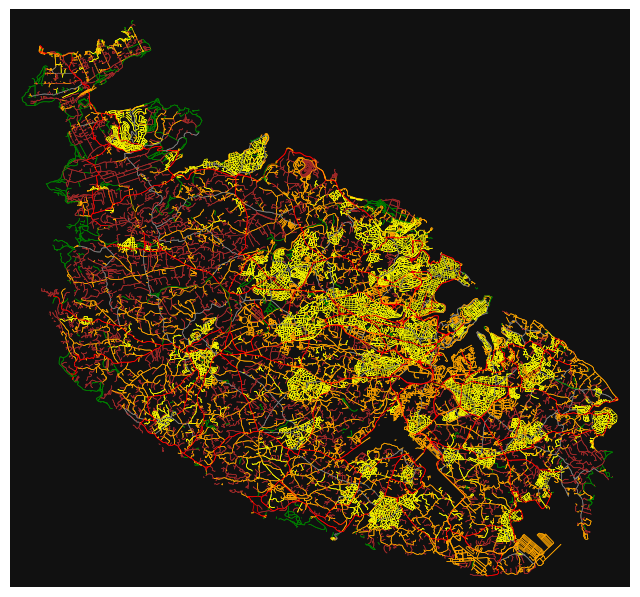

In [ ]:
#TODO remove tracks from the network

#NOTE  retain_all to get all nodes even if not connected to the main network
#fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

highway_color_map = {
    # SAFEST - Dedicated cycling infrastructure
    "cycleway": "green",        # Dedicated bike paths - safest
    "path": "green",           # Shared paths - generally safe
    
    # MODERATE - Cyclist-friendly streets  
    "living_street": "yellow",   # Shared space, pedestrian priority
    "residential": "yellow",        # Low speed, low traffic
    "pedestrian": "yellow",         # Walk/bike only areas

    # CAUTION - Mixed traffic but manageable
    "unclassified": "orange",  # Rural/local roads - variable safety
    "service": "orange",         # Parking lots, alleys - usually low speed
    #"track": "orange",            # Unpaved - may not be suitable

    # Dangerous
    "trunk":"red",
    "secondary":"red",
    "primary": "red",
    "trunk_link": "red",
    "secondary_link": "red",
    "tertiary_link": "red",
    "primary_link": "red",

    #Not suitable for urban transport / Development
    "track": "brown",
}

# Get the color for each edge based on its 'highway' attribute
edge_colors = []
highway_counts = Counter()
bikeway_counts = Counter()
cycleway_counts = Counter()
for u, v, k, data in G_bike.edges(keys=True, data=True):
    once = False

    highway = data.get("highway")
    highway = select_primary_highway(highway, highway_priority)

    bicycle = data.get("bicycle")
    bicycle = select_primary_highway(bicycle, highway_priority)

    cycleway = data.get("cycleway")
    cycleway = select_primary_highway(bicycle, highway_priority)

    #print(f"highway: {highway},\t\t bicycle: {bicycle},\t\t cycleway: {cycleway}")

    # Override dangerous roads if bicycle=yes,
    # example kappara junction there is protected cycle lane on the main road 
    match(bicycle):
        case "designated": colour = "green"
        case "yes": colour = "green"
        case _: color = highway_color_map.get(highway, "gray") 
    edge_colors.append(color)

    highway_counts[highway] += 1
    bikeway_counts[bicycle] += 1
    cycleway_counts[cycleway] += 1

print("Highway type counts:")
for highway_type, count in highway_counts.most_common():
    print(f"{highway_type}: {count}")

print("-------")
print("bikeway classification type counts:")
for bikeway_type, count in bikeway_counts.most_common():
    print(f"{bikeway_type}: {count}")

print("------")
print("cycleway type counts:")
for cycleway_type, count in cycleway_counts.most_common():
    print(f"{cycleway_type}: {count}")


fig, ax = ox.plot_graph(G_bike, node_size=0, edge_color=edge_colors, edge_linewidth=0.5)

## Edge Data

In [16]:
G_bike = ox.elevation.add_node_elevations_raster(G_bike, "../Data/rasters_COP30.tif")
G_bike = ox.elevation.add_edge_grades(G_bike)

In [ ]:
"""
u - Source node ID (starting point of the edge)
v - Target node ID (ending point of the edge)
k - Edge key (for multigraphs where multiple edges can exist between the same nodes)
data - Dictionary containing all the edge attributes/properties"""
for u, v, k, data in G_bike.edges(keys=True, data=True):
    pass


In [19]:
# Find all unique edge attributes
all_edge_attrs = set()
for u, v, k, data in G_cycle.edges(keys=True, data=True):
    all_edge_attrs.update(data.keys())

print("Available edge attributes:")
for attr in sorted(all_edge_attrs):
    print(f"  - {attr}")

NameError: name 'G_cycle' is not defined